In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import nltk
import nltk
nltk.download('punkt', download_dir=r'C:\Users\hp\AppData\Roaming\nltk_data')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import joblib
# pour (dé)sérialiser vos modèles et vos jeux de données
import joblib

# les métriques
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# pour la validation croisée du meilleur modèle
from sklearn.model_selection import cross_val_score

# les algorithmes que vous instanciez plus bas
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.naive_bayes     import MultinomialNB
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Configuration pour l'affichage en arabe
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
print("Étape 0: Chargement du dataset original")



Étape 0: Chargement du dataset original


In [4]:
df= pd.read_csv("dataset.csv", encoding='utf-8')

In [5]:
df.shape

(49864, 3)

In [6]:
df.head()

,id,text,sentiment
0,1,ما معني كل هذا ما معني كل هذا,Negative
1,2,من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل...,Negative
2,3,احلي تخلف,Negative
3,4,الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكب...,Negative
4,5,زرت فرع الخبر المطعم شكله مستهلك واللحم ماله طعم,Negative


In [7]:
print("\nValeurs uniques dans la colonne 'class':")
print(df['sentiment'].value_counts())


Valeurs uniques dans la colonne 'class':
sentiment
Negative    24932
Positive    24932
Name: count, dtype: int64


In [8]:
print("\nÉtape 1: Nettoyage des données")


Étape 1: Nettoyage des données


In [9]:
df = df.drop(df.columns[0], axis=1)


In [10]:
df.columns

Index(['text', 'sentiment'], dtype='object')

In [11]:
# Fonction de nettoyage complète
def clean_tweet(text):
    if pd.isna(text):
        return ""
    
    # Convertir en string si ce n'est pas déjà le cas
    text = str(text)
    
    # Supprimer les ;; en fin de ligne
    text = re.sub(r";;$", "", text)
    
    # Supprimer les URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Supprimer les mentions (@utilisateur)
    text = re.sub(r'@\w+', '', text)
    
    # Supprimer les hashtags (#mot) - on peut conserver le mot sans le #
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Supprimer les caractères spéciaux non arabes et non alphanumériques
    text = re.sub(r'[^\u0600-\u06FF\w\s]', ' ', text)
    
    # Normaliser les espaces multiples
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

In [12]:
# Appliquer le nettoyage
df['tweets_clean'] = df['text'].apply(clean_tweet)

In [13]:
# Afficher quelques exemples avant/après nettoyage
print("Exemples de tweets avant et après nettoyage:")
for i in range(min(10, len(df))):
    print(f"Original: {df['text'].iloc[i]}")
    print(f"Nettoyé: {df['tweets_clean'].iloc[i]}")
    print("-" * 50)

Exemples de tweets avant et après nettoyage:
Original: ما معني كل هذا ما معني كل هذا 
Nettoyé: ما معني كل هذا ما معني كل هذا
--------------------------------------------------
Original: من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل الحسنه الوحيده انها صغيره عشان ميضيعش فيها وفت اكتر من كده 
Nettoyé: من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل الحسنه الوحيده انها صغيره عشان ميضيعش فيها وفت اكتر من كده
--------------------------------------------------
Original: احلي تخلف 
Nettoyé: احلي تخلف
--------------------------------------------------
Original: الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكبر الحقاد هو بن الشيخ الذي لم يقدم للجزائر الا اللنقض والتمنشير ارجو ان يقدم لنا ما قدم في مسيرته 
Nettoyé: الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكبر الحقاد هو بن الشيخ الذي لم يقدم للجزائر الا اللنقض والتمنشير ارجو ان يقدم لنا ما قدم في مسيرته
--------------------------------------------------
Original: زرت فرع الخبر المطعم شكله مستهلك واللحم ماله طعم 
Nettoyé: زرت فرع الخبر المطعم شكل

In [14]:
print("\nÉtape 2: Normalisation du texte")


Étape 2: Normalisation du texte


In [15]:
def normalize_text(text):
    if pd.isna(text) or text == "":
        return ""
    
    # Convertir en minuscules les caractères non arabes
    text_parts = []
    for char in text:
        if '\u0600' <= char <= '\u06FF':  # Caractères arabes
            text_parts.append(char)
        else:
            text_parts.append(char.lower())
    
    text = ''.join(text_parts)
    
    # Supprimer les répétitions de lettres (plus de 2 occurrences consécutives)
    # Par exemple: سسسسسلام -> سسلام
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    return text

In [16]:
df['tweets_normalized'] = df['tweets_clean'].apply(normalize_text)

In [17]:
print("Exemples de tweets après normalisation:")
for i in range(min(12, len(df))):
    print(f"Nettoyé: {df['tweets_clean'].iloc[i]}")
    print(f"Normalisé: {df['tweets_normalized'].iloc[i]}")
    print("-" * 50)

Exemples de tweets après normalisation:
Nettoyé: ما معني كل هذا ما معني كل هذا
Normalisé: ما معني كل هذا ما معني كل هذا
--------------------------------------------------
Nettoyé: من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل الحسنه الوحيده انها صغيره عشان ميضيعش فيها وفت اكتر من كده
Normalisé: من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل الحسنه الوحيده انها صغيره عشان ميضيعش فيها وفت اكتر من كده
--------------------------------------------------
Nettoyé: احلي تخلف
Normalisé: احلي تخلف
--------------------------------------------------
Nettoyé: الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكبر الحقاد هو بن الشيخ الذي لم يقدم للجزائر الا اللنقض والتمنشير ارجو ان يقدم لنا ما قدم في مسيرته
Normalisé: الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكبر الحقاد هو بن الشيخ الذي لم يقدم للجزائر الا اللنقض والتمنشير ارجو ان يقدم لنا ما قدم في مسيرته
--------------------------------------------------
Nettoyé: زرت فرع الخبر المطعم شكله مستهلك واللحم ماله طعم
Normalisé: زرت فرع الخبر المطعم شكله مست

In [18]:
# 3. Tokenisation
print("\nÉtape 3: Tokenisation")


Étape 3: Tokenisation


In [19]:
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

In [20]:
def tokenize_arabic(text):
    if pd.isna(text) or text == "":
        return []
    
    # Tokenisation simple par espace pour l'arabe/darija
    # On peut aussi utiliser NLTK avec des règles personnalisées
    tokens = word_tokenize(text)
    
    return tokens

In [21]:
df['tokens'] = df['tweets_normalized'].apply(tokenize_arabic)


In [22]:
df['tokens'] = df['tweets_normalized'].apply(tokenize_arabic)

print("Exemples de tweets tokenisés:")
for i in range(min(5, len(df))):
    print(f"Normalisé: {df['tweets_normalized'].iloc[i]}")
    print(f"Tokens: {df['tokens'].iloc[i]}")
    print("-" * 50)

Exemples de tweets tokenisés:
Normalisé: ما معني كل هذا ما معني كل هذا
Tokens: ['ما', 'معني', 'كل', 'هذا', 'ما', 'معني', 'كل', 'هذا']
--------------------------------------------------
Normalisé: من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل الحسنه الوحيده انها صغيره عشان ميضيعش فيها وفت اكتر من كده
Tokens: ['من', 'اسوا', 'ما', 'قرات', 'ولا', 'اجد', 'حبكه', 'او', 'مغزي', 'قمه', 'الملل', 'الحسنه', 'الوحيده', 'انها', 'صغيره', 'عشان', 'ميضيعش', 'فيها', 'وفت', 'اكتر', 'من', 'كده']
--------------------------------------------------
Normalisé: احلي تخلف
Tokens: ['احلي', 'تخلف']
--------------------------------------------------
Normalisé: الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكبر الحقاد هو بن الشيخ الذي لم يقدم للجزائر الا اللنقض والتمنشير ارجو ان يقدم لنا ما قدم في مسيرته
Tokens: ['الله', 'يرحم', 'والديك', 'الشيخ', 'حفيظ', 'علي', 'هذا', 'الكلام', 'اكبر', 'الحقاد', 'هو', 'بن', 'الشيخ', 'الذي', 'لم', 'يقدم', 'للجزائر', 'الا', 'اللنقض', 'والتمنشير', 'ارجو', 'ان', 'يقدم', 'لنا', 'ما', 'ق

In [23]:
# 4. Gestion des mots vides (stopwords)
print("\nÉtape 4: Gestion des mots vides (stopwords)")


Étape 4: Gestion des mots vides (stopwords)


In [24]:
 #Définir une liste de stopwords en arabe/darija
# Cette liste est un exemple, vous devrez la personnaliser pour la darija marocaine
try:
    arabic_stopwords = set(stopwords.words('arabic'))
except LookupError:
    nltk.download('stopwords')
    arabic_stopwords = set(stopwords.words('arabic'))

# Ajouter des stopwords spécifiques à la darija marocaine
darija_stopwords = {
    'و', 'في', 'هذا', 'يا', 'على', 'من', 'ما', 'لي', 'هاد', 'كان', 
    'هي', 'هو', 'غادي', 'باش', 'دابا', 'كنت', 'كن', 'كيف', 'واخا', 
    'واش', 'عند', 'عندي', 'كاين', 'كاينة', 'ديال', 'ديالي', 'ديالك',
    'فيه', 'فيها', 'انا', 'انت', 'هوا', 'هيا', 'احنا', 'نتا', 'نتي'
}


In [25]:
# Combiner les deux ensembles de stopwords
stopwords_set = arabic_stopwords.union(darija_stopwords)

In [26]:
def remove_stopwords(tokens):
    if not tokens:
        return []
    
    return [token for token in tokens if token not in stopwords_set]

df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)

In [27]:
print("Exemples de tweets après suppression des stopwords:")
for i in range(min(5, len(df))):
    print(f"Tokens avec stopwords: {df['tokens'].iloc[i]}")
    print(f"Tokens sans stopwords: {df['tokens_no_stopwords'].iloc[i]}")
    print("-" * 50)

Exemples de tweets après suppression des stopwords:
Tokens avec stopwords: ['ما', 'معني', 'كل', 'هذا', 'ما', 'معني', 'كل', 'هذا']
Tokens sans stopwords: ['معني', 'معني']
--------------------------------------------------
Tokens avec stopwords: ['من', 'اسوا', 'ما', 'قرات', 'ولا', 'اجد', 'حبكه', 'او', 'مغزي', 'قمه', 'الملل', 'الحسنه', 'الوحيده', 'انها', 'صغيره', 'عشان', 'ميضيعش', 'فيها', 'وفت', 'اكتر', 'من', 'كده']
Tokens sans stopwords: ['اسوا', 'قرات', 'اجد', 'حبكه', 'او', 'مغزي', 'قمه', 'الملل', 'الحسنه', 'الوحيده', 'انها', 'صغيره', 'عشان', 'ميضيعش', 'وفت', 'اكتر', 'كده']
--------------------------------------------------
Tokens avec stopwords: ['احلي', 'تخلف']
Tokens sans stopwords: ['احلي', 'تخلف']
--------------------------------------------------
Tokens avec stopwords: ['الله', 'يرحم', 'والديك', 'الشيخ', 'حفيظ', 'علي', 'هذا', 'الكلام', 'اكبر', 'الحقاد', 'هو', 'بن', 'الشيخ', 'الذي', 'لم', 'يقدم', 'للجزائر', 'الا', 'اللنقض', 'والتمنشير', 'ارجو', 'ان', 'يقدم', 'لنا', 'ما', 'قدم', 'في

In [28]:
# 5. Lemmatisation/Racinisation (Stemming)
print("\nÉtape 5: Lemmatisation/Racinisation")


Étape 5: Lemmatisation/Racinisation


In [29]:
# Remarque: Pour une stématisation complète de l'arabe, il est recommandé d'utiliser
# des bibliothèques spécialisées comme PyArabic, Farasa ou CAMeL Tools.
# Ici, nous utilisons une approche simplifiée pour la démonstration.

# Fonction de racinisation simple (à remplacer par une solution plus robuste)
def simple_arabic_stem(word):
    # Cette fonction est très simplifiée et ne doit être utilisée qu'à des fins de démonstration
    # Supprime les préfixes courants en arabe
    prefixes = ['ال', 'بال', 'كال', 'لل', 'و', 'ف', 'ب', 'ل', 'س', 'ي', 'ت', 'ن']
    
    for prefix in prefixes:
        if word.startswith(prefix) and len(word) > len(prefix) + 2:
            word = word[len(prefix):]
            break
    
    # Supprime les suffixes courants en arabe
    suffixes = ['ون', 'ين', 'ات', 'ة', 'ه', 'ي', 'ك', 'ها', 'هم', 'هن', 'كم', 'كن', 'نا']
    
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            word = word[:-len(suffix)]
            break
    
    return word

In [30]:
def stem_tokens(tokens):
    if not tokens:
        return []
    
    return [simple_arabic_stem(token) for token in tokens]

In [31]:
df['tokens_stemmed'] = df['tokens_no_stopwords'].apply(stem_tokens)
print("Exemples de tweets après racinisation:")
for i in range(min(5, len(df))):
    print(f"Tokens sans stopwords: {df['tokens_no_stopwords'].iloc[i]}")
    print(f"Tokens racinisés: {df['tokens_stemmed'].iloc[i]}")
    print("-" * 50)

Exemples de tweets après racinisation:
Tokens sans stopwords: ['معني', 'معني']
Tokens racinisés: ['معن', 'معن']
--------------------------------------------------
Tokens sans stopwords: ['اسوا', 'قرات', 'اجد', 'حبكه', 'او', 'مغزي', 'قمه', 'الملل', 'الحسنه', 'الوحيده', 'انها', 'صغيره', 'عشان', 'ميضيعش', 'وفت', 'اكتر', 'كده']
Tokens racinisés: ['اسوا', 'قرات', 'اجد', 'حبك', 'او', 'مغز', 'قمه', 'ملل', 'حسن', 'وحيد', 'انها', 'صغير', 'عشان', 'ميضيعش', 'وفت', 'اكتر', 'كده']
--------------------------------------------------
Tokens sans stopwords: ['احلي', 'تخلف']
Tokens racinisés: ['احل', 'خلف']
--------------------------------------------------
Tokens sans stopwords: ['الله', 'يرحم', 'والديك', 'الشيخ', 'حفيظ', 'علي', 'الكلام', 'اكبر', 'الحقاد', 'بن', 'الشيخ', 'يقدم', 'للجزائر', 'الا', 'اللنقض', 'والتمنشير', 'ارجو', 'ان', 'يقدم', 'قدم', 'مسيرته']
Tokens racinisés: ['الل', 'رحم', 'الدي', 'شيخ', 'حفيظ', 'علي', 'كلام', 'اكبر', 'حقاد', 'بن', 'شيخ', 'قدم', 'جزائر', 'الا', 'لنقض', 'التمنشير', 'ارج

In [32]:
# Rejoindre les tokens pour former un texte prétraité complet
df['preprocessed_text'] = df['tokens_stemmed'].apply(lambda x: ' '.join(x))

In [33]:
# 6. Vérification des étiquettes
print("\nÉtape 6: Vérification et encodage des étiquettes")


Étape 6: Vérification et encodage des étiquettes


In [34]:
df['sentiment'] = df['sentiment'].map({'Positive': 0, 'Negative': 1})



In [35]:
print("\nÉtape 7: Suppression des doublons")


Étape 7: Suppression des doublons


In [36]:
df

,text,sentiment,tweets_clean,tweets_normalized,tokens,tokens_no_stopwords,tokens_stemmed,preprocessed_text
0,ما معني كل هذا ما معني كل هذا,1,ما معني كل هذا ما معني كل هذا,ما معني كل هذا ما معني كل هذا,"[ما, معني, كل, هذا, ما, معني, كل, هذا]","[معني, معني]","[معن, معن]",معن معن
1,من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل...,1,من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل...,من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل...,"[من, اسوا, ما, قرات, ولا, اجد, حبكه, او, مغزي,...","[اسوا, قرات, اجد, حبكه, او, مغزي, قمه, الملل, ...","[اسوا, قرات, اجد, حبك, او, مغز, قمه, ملل, حسن,...",اسوا قرات اجد حبك او مغز قمه ملل حسن وحيد انها...
2,احلي تخلف,1,احلي تخلف,احلي تخلف,"[احلي, تخلف]","[احلي, تخلف]","[احل, خلف]",احل خلف
3,الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكب...,1,الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكب...,الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكب...,"[الله, يرحم, والديك, الشيخ, حفيظ, علي, هذا, ال...","[الله, يرحم, والديك, الشيخ, حفيظ, علي, الكلام,...","[الل, رحم, الدي, شيخ, حفيظ, علي, كلام, اكبر, ح...",الل رحم الدي شيخ حفيظ علي كلام اكبر حقاد بن شي...
4,زرت فرع الخبر المطعم شكله مستهلك واللحم ماله طعم,1,زرت فرع الخبر المطعم شكله مستهلك واللحم ماله طعم,زرت فرع الخبر المطعم شكله مستهلك واللحم ماله طعم,"[زرت, فرع, الخبر, المطعم, شكله, مستهلك, واللحم...","[زرت, فرع, الخبر, المطعم, شكله, مستهلك, واللحم...","[زرت, فرع, خبر, مطعم, شكل, مستهل, اللحم, مال, ...",زرت فرع خبر مطعم شكل مستهل اللحم مال طعم
...,...,...,...,...,...,...,...,...
49859,تعرفون سيدنا جبريل له كم جناح اقراء واعرف قال ...,0,تعرفون سيدنا جبريل له كم جناح اقراء واعرف قال ...,تعرفون سيدنا جبريل له كم جناح اقراء واعرف قال ...,"[تعرفون, سيدنا, جبريل, له, كم, جناح, اقراء, وا...","[تعرفون, سيدنا, جبريل, جناح, اقراء, واعرف, قال...","[عرف, يدنا, جبريل, جناح, اقراء, اعرف, قال, رسو...",عرف يدنا جبريل جناح اقراء اعرف قال رسول الل صل...
49860,رائعه وتصويره جميله,0,رائعه وتصويره جميله,رائعه وتصويره جميله,"[رائعه, وتصويره, جميله]","[رائعه, وتصويره, جميله]","[رائع, تصوير, جميل]",رائع تصوير جميل
49861,مقالات تلامس وجدان المواطن العربي ت سل ط الضوء...,0,مقالات تلامس وجدان المواطن العربي ت سل ط الضوء...,مقالات تلامس وجدان المواطن العربي ت سل ط الضوء...,"[مقالات, تلامس, وجدان, المواطن, العربي, ت, سل,...","[مقالات, تلامس, وجدان, المواطن, العربي, سل, ال...","[مقال, لامس, جدان, مواطن, عرب, سل, ضوء, علي, ا...",مقال لامس جدان مواطن عرب سل ضوء علي امور غفل ع...
49862,وحدك يا جلول,0,وحدك يا جلول,وحدك يا جلول,"[وحدك, يا, جلول]","[وحدك, جلول]","[حدك, جلول]",حدك جلول


In [37]:
duplicate_count = df.duplicated(subset=['preprocessed_text']).sum()
print(f"Nombre de tweets en double: {duplicate_count}")

Nombre de tweets en double: 313


In [38]:
df_no_duplicates = df.drop_duplicates(subset=['preprocessed_text'])
print(f"Dimensions après suppression des doublons: {df_no_duplicates.shape}")

Dimensions après suppression des doublons: (49551, 8)


In [39]:
df.head()

,text,sentiment,tweets_clean,tweets_normalized,tokens,tokens_no_stopwords,tokens_stemmed,preprocessed_text
0,ما معني كل هذا ما معني كل هذا,1,ما معني كل هذا ما معني كل هذا,ما معني كل هذا ما معني كل هذا,"[ما, معني, كل, هذا, ما, معني, كل, هذا]","[معني, معني]","[معن, معن]",معن معن
1,من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل...,1,من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل...,من اسوا ما قرات ولا اجد حبكه او مغزي قمه الملل...,"[من, اسوا, ما, قرات, ولا, اجد, حبكه, او, مغزي,...","[اسوا, قرات, اجد, حبكه, او, مغزي, قمه, الملل, ...","[اسوا, قرات, اجد, حبك, او, مغز, قمه, ملل, حسن,...",اسوا قرات اجد حبك او مغز قمه ملل حسن وحيد انها...
2,احلي تخلف,1,احلي تخلف,احلي تخلف,"[احلي, تخلف]","[احلي, تخلف]","[احل, خلف]",احل خلف
3,الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكب...,1,الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكب...,الله يرحم والديك الشيخ حفيظ علي هذا الكلام اكب...,"[الله, يرحم, والديك, الشيخ, حفيظ, علي, هذا, ال...","[الله, يرحم, والديك, الشيخ, حفيظ, علي, الكلام,...","[الل, رحم, الدي, شيخ, حفيظ, علي, كلام, اكبر, ح...",الل رحم الدي شيخ حفيظ علي كلام اكبر حقاد بن شي...
4,زرت فرع الخبر المطعم شكله مستهلك واللحم ماله طعم,1,زرت فرع الخبر المطعم شكله مستهلك واللحم ماله طعم,زرت فرع الخبر المطعم شكله مستهلك واللحم ماله طعم,"[زرت, فرع, الخبر, المطعم, شكله, مستهلك, واللحم...","[زرت, فرع, الخبر, المطعم, شكله, مستهلك, واللحم...","[زرت, فرع, خبر, مطعم, شكل, مستهل, اللحم, مال, ...",زرت فرع خبر مطعم شكل مستهل اللحم مال طعم


In [40]:
# 8. Vectorisation
print("\nÉtape 8: Vectorisation")


Étape 8: Vectorisation


In [41]:
# Vectorisation TF-IDF
vectorizer = TfidfVectorizer(
    min_df=2,         # Ignorer les termes qui apparaissent dans moins de 2 documents
    max_df=0.85,      # Ignorer les termes qui apparaissent dans plus de 85% des documents
    ngram_range=(1, 2)  # Unigrams et bigrams
)

In [42]:
# Créer la matrice TF-IDF
X_tfidf = vectorizer.fit_transform(df_no_duplicates['preprocessed_text'])

In [43]:
print(f"Dimensions de la matrice TF-IDF: {X_tfidf.shape}")
print(f"Nombre de caractéristiques: {len(vectorizer.get_feature_names_out())}")

Dimensions de la matrice TF-IDF: (49551, 238906)
Nombre de caractéristiques: 238906


In [44]:
# Afficher les 10 premières caractéristiques
print("Premières caractéristiques:")
print(vectorizer.get_feature_names_out()[:10])

Premières caractéristiques:
['ءات' 'ءه' 'ؤاخذ' 'ؤاخذ فعل' 'ؤاد' 'ؤاد ليم' 'ؤاد مهندس' 'ؤاد نتر'
 'ؤاد نجم' 'ؤاد هذا']


In [45]:
# 9. Équilibrage des classes
print("\nÉtape 9: Analyse de l'équilibre des classes")


Étape 9: Analyse de l'équilibre des classes


In [46]:
 #Distribution des classes de sentiment
print("Distribution des classes de sentiment:")
print(df_no_duplicates['sentiment'].value_counts())


Distribution des classes de sentiment:
sentiment
1    24777
0    24774
Name: count, dtype: int64


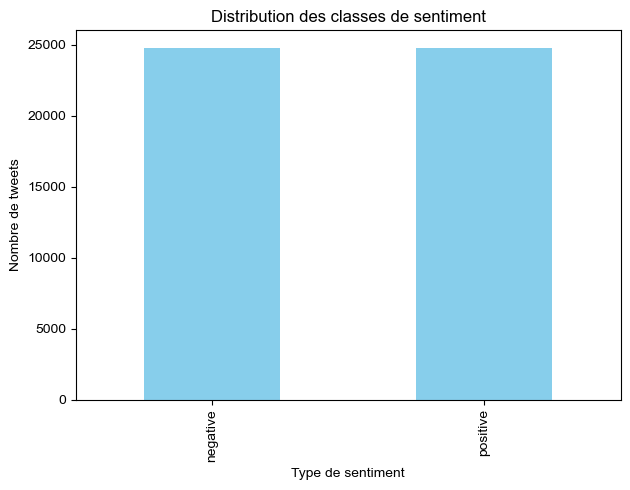

In [47]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_no_duplicates['sentiment'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution des classes de sentiment')
plt.xlabel('Type de sentiment')
plt.ylabel('Nombre de tweets')
plt.xticks(ticks=[0, 1], labels=["negative","positive"])  # 0 -> positive, 1 -> negative

plt.tight_layout()
plt.show()


In [48]:
 #10.

In [52]:
# Préparer le dataframe final pour l'export
df_final = df_no_duplicates[[
    'text',                # Texte original
    'tweets_clean',          # Texte nettoyé
    'preprocessed_text',     # Texte prétraité complet
    'sentiment'  # Étiquettes de sentiment
     # Étiquettes de dialecte
]]


In [53]:
df_final.to_csv("MAC_corpus_clean.csv", index=False)
print("Données prétraitées sauvegardées sous 'MAC_corpus_clean.csv'")

Données prétraitées sauvegardées sous 'MAC_corpus_clean.csv'


In [54]:
print("\nPréparation des données pour l'apprentissage automatique")


Préparation des données pour l'apprentissage automatique


In [55]:
# Diviser en ensembles d'entraînement et de test
X = X_tfidf
y = df_no_duplicates['sentiment'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y  ,
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Stratifier selon le sentiment
)

print(f"Ensemble d'entraînement: {X_train.shape[0]} exemples")
print(f"Ensemble de test: {X_test.shape[0]} exemples")

Ensemble d'entraînement: 39640 exemples
Ensemble de test: 9911 exemples


In [56]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn import metrics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def multiclass_roc_auc_score(y_true, y_pred, average="macro"):
    from sklearn.preprocessing import LabelBinarizer
    lb = LabelBinarizer()
    lb.fit(y_true)
    y_true_bin = lb.transform(y_true)
    y_pred_bin = lb.transform(y_pred)
    return roc_auc_score(y_true_bin, y_pred_bin, average=average)

def evaluate_model(model, X_train, y_train):
    """Cross-validation sur accuracy"""
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=4)

def Model_Evaluation1(model, model_name, X_train, y_train, X_test, y_test, result_tabulation):
    # 1) Prédictions
    model_pred = model.predict(X_test)
    
    # 2) Matrice de confusion
    cm = confusion_matrix(y_test, model_pred)
    conf_matrix = pd.DataFrame(
        data=cm,
        columns=[f'P_{cls}' for cls in np.unique(y_test)],
        index=[f'A_{cls}' for cls in np.unique(y_test)]
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="YlGnBu")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()

    # 3) Rapport de classification
    print(f"\nClassification Report – {model_name}\n")
    print(classification_report(y_test, model_pred, zero_division=0))

    # 4) Validation croisée
    cv_accuracy = evaluate_model(model, X_train, y_train)

    # 5) Récapitulatif des métriques
    model_eva = pd.Series({
        'Model'          : model_name,
        'AUC Score'      : multiclass_roc_auc_score(y_test, model_pred),
        'MCC'            : metrics.matthews_corrcoef(y_test, model_pred),
        'Precision Score': metrics.precision_score(y_test, model_pred, average='weighted', zero_division=0),
        'Recall Score'   : metrics.recall_score(y_test, model_pred, average='weighted', zero_division=0),
        'f1-score'       : metrics.f1_score(y_test, model_pred, average='weighted', zero_division=0),
        'Accuracy Score' : metrics.accuracy_score(y_test, model_pred),
        'Train Accuracy' : model.score(X_train, y_train),
        'CV'             : np.mean(cv_accuracy)
    })

    print(f"\nMetrics – {model_name}\n{model_eva}\n")

    # 6) Mettre à jour la table des résultats
    result_tabulation = pd.concat([result_tabulation, model_eva.to_frame().T], ignore_index=True)

    return result_tabulation


In [57]:
cols = ['Model', 'AUC Score','MCC', 'Precision Score', 'Recall Score','f1-score','Accuracy Score','Train Accuracy','CV']

In [58]:
result_tabulation = pd.DataFrame(columns = cols)
result_tabulation_rse1 = pd.DataFrame(columns = cols)


In [59]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC



Decision Tree TF-IDF CV accuracy: [0.74608981 0.75063068 0.75668517 0.75176589 0.75302725]
Moyenne: 0.7516, Écart-type: 0.0034


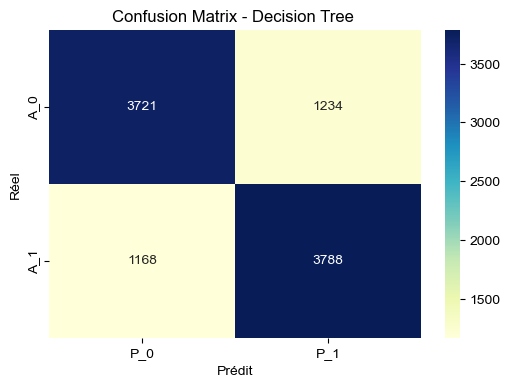


Classification Report – Decision Tree 

              precision    recall  f1-score   support

           0       0.76      0.75      0.76      4955
           1       0.75      0.76      0.76      4956

    accuracy                           0.76      9911
   macro avg       0.76      0.76      0.76      9911
weighted avg       0.76      0.76      0.76      9911


Metrics – Decision Tree 
Model              Decision Tree 
AUC Score                0.757642
MCC                      0.515331
Precision Score          0.757688
Recall Score             0.757643
f1-score                 0.757632
Accuracy Score           0.757643
Train Accuracy            0.99894
CV                       0.749912
dtype: object



In [60]:
# --- Decision Tree sur TF-IDF ---
dt_tfidf = DecisionTreeClassifier(random_state=200)
cv_scores = cross_val_score(dt_tfidf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
dt_tfidf.fit(X_train, y_train)
result_tabulation = Model_Evaluation1(dt_tfidf, "Decision Tree ", X_train , y_train, X_test, y_test, result_tabulation)


Decision Tree TF-IDF CV accuracy: [0.8502775  0.84977296 0.85406155 0.84106963 0.85103431]
Moyenne: 0.8492, Écart-type: 0.0043


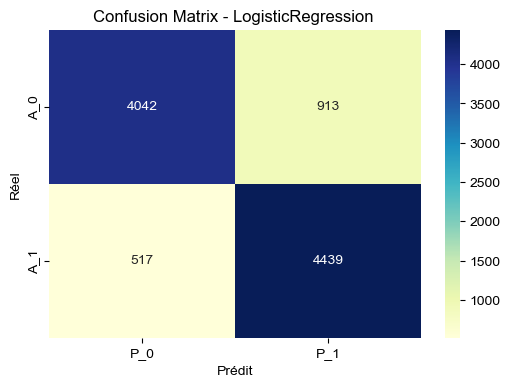


Classification Report – LogisticRegression 

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      4955
           1       0.83      0.90      0.86      4956

    accuracy                           0.86      9911
   macro avg       0.86      0.86      0.86      9911
weighted avg       0.86      0.86      0.86      9911


Metrics – LogisticRegression 
Model              LogisticRegression 
AUC Score                     0.855712
MCC                           0.713712
Precision Score               0.858001
Recall Score                  0.855716
f1-score                      0.855485
Accuracy Score                0.855716
Train Accuracy                0.917104
CV                            0.848625
dtype: object



In [61]:
# --- Decision Tree sur TF-IDF ---
lg_tfidf =LogisticRegression(random_state=200)
cv_scores = cross_val_score(lg_tfidf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
lg_tfidf.fit(X_train, y_train)
result_tabulation = Model_Evaluation1(lg_tfidf, "LogisticRegression ", X_train, y_train, X_test, y_test, result_tabulation)


Decision Tree TF-IDF CV accuracy: [0.85519677 0.8570888  0.8592331  0.84914228 0.85860242]
Moyenne: 0.8559, Écart-type: 0.0036


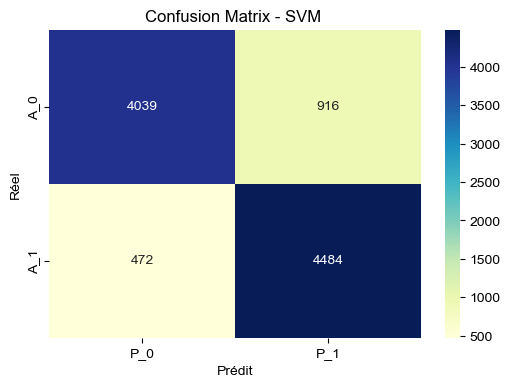


Classification Report – SVM 

              precision    recall  f1-score   support

           0       0.90      0.82      0.85      4955
           1       0.83      0.90      0.87      4956

    accuracy                           0.86      9911
   macro avg       0.86      0.86      0.86      9911
weighted avg       0.86      0.86      0.86      9911



KeyboardInterrupt: 

In [62]:
# --- Decision Tree sur TF-IDF ---
svm_tfidf =SVC()
cv_scores = cross_val_score(svm_tfidf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
svm_tfidf.fit(X_train, y_train)
result_tabulation = Model_Evaluation1(svm_tfidf, "SVM ", X_train, y_train, X_test, y_test, result_tabulation)


Decision Tree TF-IDF CV accuracy: [0.52371342 0.51677598 0.51892028 0.51450555 0.51942482]
Moyenne: 0.5187, Écart-type: 0.0031


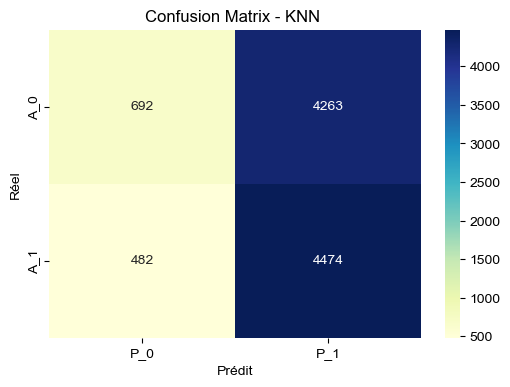


Classification Report – KNN 

              precision    recall  f1-score   support

           0       0.59      0.14      0.23      4955
           1       0.51      0.90      0.65      4956

    accuracy                           0.52      9911
   macro avg       0.55      0.52      0.44      9911
weighted avg       0.55      0.52      0.44      9911


Metrics – KNN 
Model                  KNN 
AUC Score          0.521201
MCC                0.065607
Precision Score    0.550753
Recall Score       0.521239
f1-score           0.439664
Accuracy Score     0.521239
Train Accuracy     0.639304
CV                 0.518302
dtype: object



In [ ]:
# --- Decision Tree sur TF-IDF ---
KNN =KNeighborsClassifier()
cv_scores = cross_val_score(KNN, X_train, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
KNN.fit(X_train , y_train)
result_tabulation = Model_Evaluation1(KNN, "KNN ", X_train  , y_train, X_test , y_test, result_tabulation)


In [ ]:
result_tabulation

,Model,AUC Score,MCC,Precision Score,Recall Score,f1-score,Accuracy Score,Train Accuracy,CV
0,Decision Tree,0.757642,0.515331,0.757688,0.757643,0.757632,0.757643,0.99894,0.749912
1,LogisticRegression,0.855712,0.713712,0.858001,0.855716,0.855485,0.855716,0.917104,0.848625
2,SVM,0.859949,0.722812,0.862865,0.859954,0.859671,0.859954,0.987614,0.855134
3,KNN,0.521201,0.065607,0.550753,0.521239,0.439664,0.521239,0.639304,0.518302


In [66]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Logistic Regression params: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 1000, 'C': 10.0}


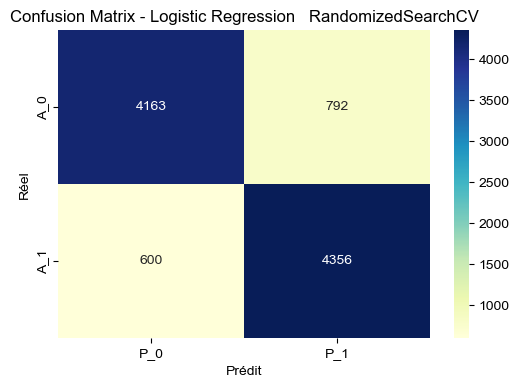


Classification Report – Logistic Regression   RandomizedSearchCV

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4955
           1       0.85      0.88      0.86      4956

    accuracy                           0.86      9911
   macro avg       0.86      0.86      0.86      9911
weighted avg       0.86      0.86      0.86      9911


Metrics – Logistic Regression   RandomizedSearchCV
Model              Logistic Regression   RandomizedSearchCV
AUC Score                                          0.859548
MCC                                                0.719639
Precision Score                                     0.86009
Recall Score                                        0.85955
f1-score                                           0.859497
Accuracy Score                                      0.85955
Train Accuracy                                     0.990767
CV                                                 0.854743
dtype: object


In [67]:
param_dist_lr = {
    'C': np.logspace(-3, 3, 10),
    'solver': ['lbfgs', 'saga'],
    'penalty': ['l2'],
    'max_iter': [1000]
}

rs_lr = RandomizedSearchCV(
    LogisticRegression(),
    param_dist_lr,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    n_jobs=4,
    verbose=1,
    random_state=42
)

rs_lr.fit(X_train , y_train)
print("Best Logistic Regression params:", rs_lr.best_params_)

best_lr = rs_lr.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_lr,
    "Logistic Regression   RandomizedSearchCV",
    X_train , y_train,
    X_test , y_test,
    result_tabulation_rse1
)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best SVC params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 2.1544346900318843}


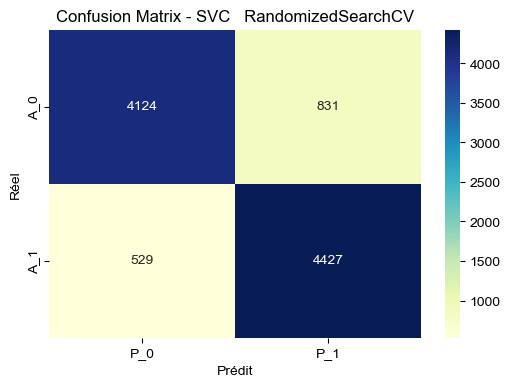


Classification Report – SVC   RandomizedSearchCV

              precision    recall  f1-score   support

           0       0.89      0.83      0.86      4955
           1       0.84      0.89      0.87      4956

    accuracy                           0.86      9911
   macro avg       0.86      0.86      0.86      9911
weighted avg       0.86      0.86      0.86      9911


Metrics – SVC   RandomizedSearchCV
Model              SVC   RandomizedSearchCV
AUC Score                          0.862776
MCC                                0.726907
Precision Score                     0.86413
Recall Score                       0.862779
f1-score                           0.862651
Accuracy Score                     0.862779
Train Accuracy                     0.997906
CV                                 0.858741
dtype: object



In [70]:
param_dist_svc = {
    'C': np.logspace(-3, 2, 10),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

rs_svc = RandomizedSearchCV(
    SVC(),
    param_dist_svc,
    n_iter=15,
    scoring='accuracy',
    cv=5,
    n_jobs=4,
    verbose=1,
    random_state=42
)

rs_svc.fit(X_train , y_train)
print("Best SVC params:", rs_svc.best_params_)

best_svc = rs_svc.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_svc,
    "SVC   RandomizedSearchCV",
    X_train , y_train,
    X_test, y_test,
    result_tabulation_rse1
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best KNN params: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'euclidean'}


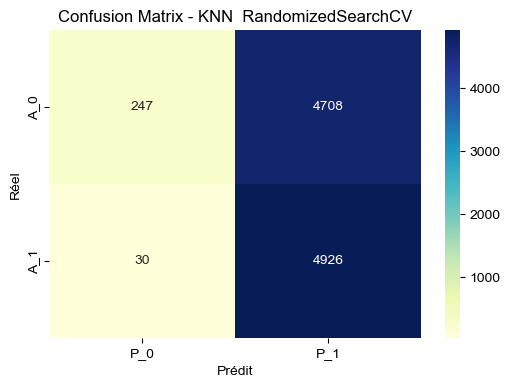


Classification Report – KNN  RandomizedSearchCV

              precision    recall  f1-score   support

           0       0.89      0.05      0.09      4955
           1       0.51      0.99      0.68      4956

    accuracy                           0.52      9911
   macro avg       0.70      0.52      0.38      9911
weighted avg       0.70      0.52      0.38      9911


Metrics – KNN  RandomizedSearchCV
Model              KNN  RandomizedSearchCV
AUC Score                         0.521898
MCC                               0.132853
Precision Score                   0.701486
Recall Score                      0.521945
f1-score                          0.384867
Accuracy Score                    0.521945
Train Accuracy                     0.99894
CV                                0.517684
dtype: object



In [71]:
param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

rs_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_dist_knn,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    n_jobs=6,
    verbose=1,
    random_state=42
)

rs_knn.fit(X_train , y_train)
print("Best KNN params:", rs_knn.best_params_)

best_knn = rs_knn.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_knn,
    "KNN  RandomizedSearchCV",
    X_train , y_train,
    X_test , y_test,
    result_tabulation_rse1
)

In [72]:
result_tabulation_rse1

,Model,AUC Score,MCC,Precision Score,Recall Score,f1-score,Accuracy Score,Train Accuracy,CV
0,Logistic Regression RandomizedSearchCV,0.859548,0.719639,0.86009,0.85955,0.859497,0.85955,0.990767,0.854743
1,SVC RandomizedSearchCV,0.862776,0.726907,0.86413,0.862779,0.862651,0.862779,0.997906,0.858741
2,KNN RandomizedSearchCV,0.521898,0.132853,0.701486,0.521945,0.384867,0.521945,0.99894,0.517684


In [73]:
vote_classifi = VotingClassifier(estimators=[('Logistic Regression RandomizedSearchCV",',rs_lr ), ('SVC  RandomizedSearchCV', rs_svc)
 ],voting='soft')
best_model =vote_classifi.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits


KeyboardInterrupt: 

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
           ÉVALUATION DES PERFORMANCES - VOTING CLASSIFIER

🎯 MÉTRIQUES GLOBALES
----------------------------------------
📊 Accuracy (Précision globale)    : 0.8622 (86.22%)
📊 Precision (moyenne pondérée)    : 0.8624
📊 Recall (moyenne pondérée)       : 0.8622
📊 F1-Score (moyenne pondérée)     : 0.8622
📊 AUC-ROC                         : Non disponible (vote 'hard')

🔍 MATRICE DE CONFUSION
----------------------------------------
Matrice de confusion (lignes=réel, colonnes=prédiction):
[[4214  741]
 [ 625 4331]]


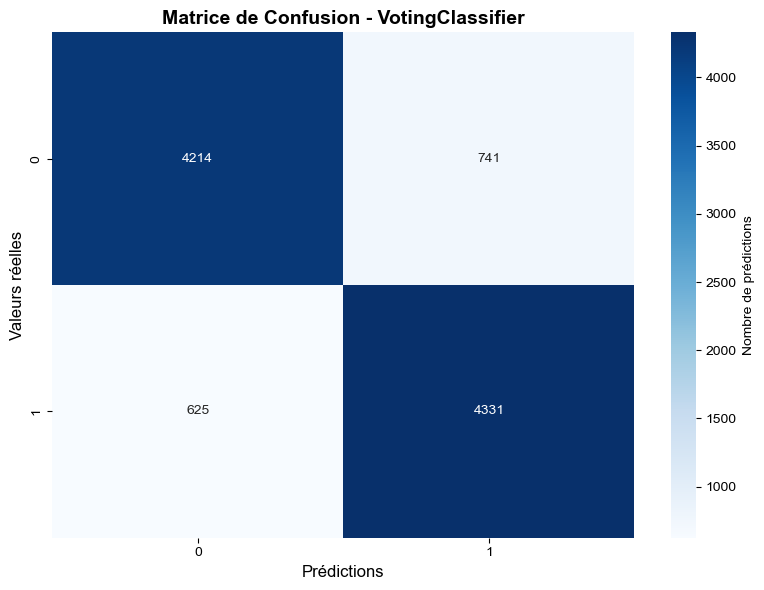


📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4955
           1       0.85      0.87      0.86      4956

    accuracy                           0.86      9911
   macro avg       0.86      0.86      0.86      9911
weighted avg       0.86      0.86      0.86      9911



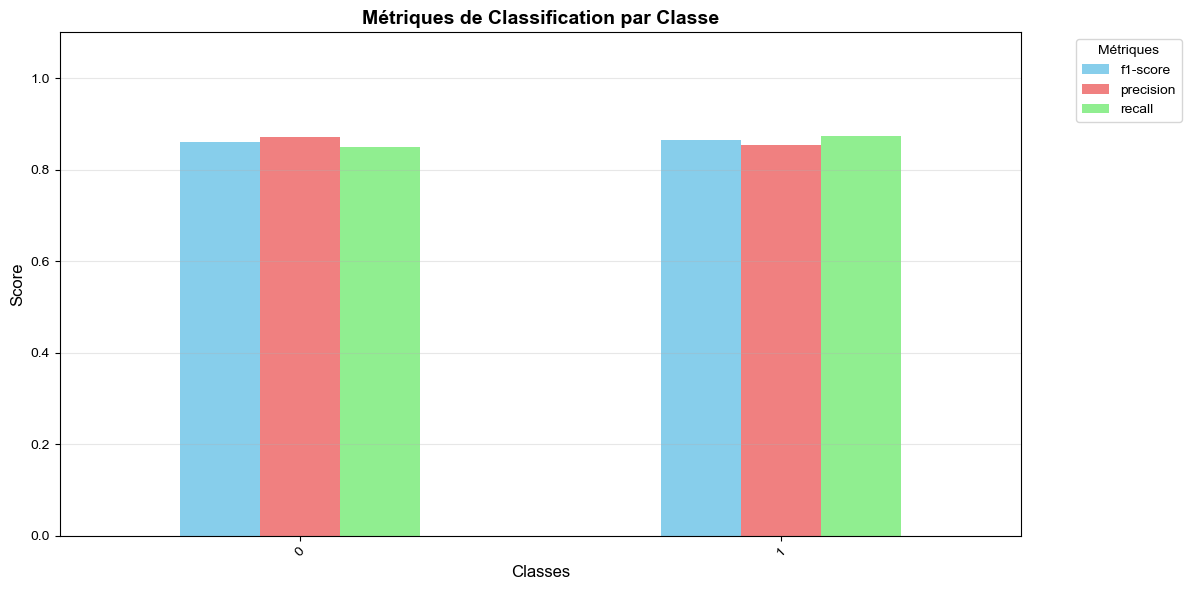


🔎 ANALYSE DES ERREURS
------------------------------
Total des prédictions           : 9911
Prédictions correctes           : 8545
Prédictions incorrectes         : 1366
Taux d'erreur                   : 13.78%

                    RÉSUMÉ FINAL
🏆 Modèle utilisé               : VotingClassifier
🏆 Type de vote                 : Hard
🏆 Accuracy finale              : 0.8622 (86.22%)
🏆 F1-Score global              : 0.8622
🏆 Stratégie                   : Vote majoritaire
🏆 Modèles combinés             : Logistic Regression + SVC


In [76]:
# Importation des bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score
)
import pandas as pd

    
    # Reconfigurer avec vote 'hard'
vote_classifi_hard = VotingClassifier(
        estimators=[
            ('Logistic Regression RandomizedSearchCV', rs_lr), 
            ('SVC RandomizedSearchCV', rs_svc)
        ],
        voting='hard'
    )
best_model = vote_classifi_hard.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_pred_proba = None
proba_available = False

print("="*70)
print("           ÉVALUATION DES PERFORMANCES - VOTING CLASSIFIER")
print("="*70)

# 1. MÉTRIQUES GLOBALES
print("\n🎯 MÉTRIQUES GLOBALES")
print("-" * 40)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"📊 Accuracy (Précision globale)    : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📊 Precision (moyenne pondérée)    : {precision:.4f}")
print(f"📊 Recall (moyenne pondérée)       : {recall:.4f}")
print(f"📊 F1-Score (moyenne pondérée)     : {f1:.4f}")

# AUC si disponible et problème binaire
if len(np.unique(y_test)) == 2 and proba_available:
    auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    print(f"📊 AUC-ROC                         : {auc:.4f}")
elif len(np.unique(y_test)) == 2:
    print(f"📊 AUC-ROC                         : Non disponible (vote 'hard')")

# 2. MATRICE DE CONFUSION
print("\n🔍 MATRICE DE CONFUSION")
print("-" * 40)
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion (lignes=réel, colonnes=prédiction):")
print(cm)

# Visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y_test)), 
            yticklabels=sorted(np.unique(y_test)),
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title('Matrice de Confusion - VotingClassifier', fontsize=14, fontweight='bold')
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Valeurs réelles', fontsize=12)
plt.tight_layout()
plt.show()

# 3. RAPPORT DE CLASSIFICATION DÉTAILLÉ
print("\n📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("-" * 50)
print(classification_report(y_test, y_pred))

# Visualisation du rapport de classification
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Extraire les classes (exclure les moyennes)
classes = [key for key in report_dict.keys() if key not in ['accuracy', 'macro avg', 'weighted avg']]
metrics = ['precision', 'recall', 'f1-score']

# Créer le DataFrame pour la visualisation
data = []
for cls in classes:
    for metric in metrics:
        data.append({
            'Classe': cls,
            'Métrique': metric,
            'Valeur': report_dict[cls][metric]
        })

df_report = pd.DataFrame(data)

# Graphique en barres groupées
plt.figure(figsize=(12, 6))
pivot_df = df_report.pivot(index='Classe', columns='Métrique', values='Valeur')
pivot_df.plot(kind='bar', ax=plt.gca(), color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Métriques de Classification par Classe', fontsize=14, fontweight='bold')
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(title='Métriques', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. ANALYSE DES ERREURS
print("\n🔎 ANALYSE DES ERREURS")
print("-" * 30)
total_predictions = len(y_test)
correct_predictions = (y_pred == y_test).sum()
incorrect_predictions = total_predictions - correct_predictions

print(f"Total des prédictions           : {total_predictions}")
print(f"Prédictions correctes           : {correct_predictions}")
print(f"Prédictions incorrectes         : {incorrect_predictions}")
print(f"Taux d'erreur                   : {(incorrect_predictions/total_predictions)*100:.2f}%")

# 5. RÉSUMÉ FINAL
print("\n" + "="*70)
print("                    RÉSUMÉ FINAL")
print("="*70)
print(f"🏆 Modèle utilisé               : VotingClassifier")
print(f"🏆 Type de vote                 : {'Soft' if proba_available else 'Hard'}")
print(f"🏆 Accuracy finale              : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"🏆 F1-Score global              : {f1:.4f}")

if proba_available:
    print("🏆 Stratégie                   : Combinaison des probabilités")
else:
    print("🏆 Stratégie                   : Vote majoritaire")

print("🏆 Modèles combinés             : Logistic Regression + SVC")
print("="*70)